In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

shop = pd.read_csv("shop_smart_ecommerce.csv")

In [91]:
shop.info()
shop.describe()
shop.head(25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [92]:
# cols = ["Month", "VisitorType", "Weekend", "Revenue"]
# shop = pd.get_dummies(shop, columns=cols, drop_first=True).astype(int)

In [93]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
shop["Month"] = le.fit_transform(shop["Month"])
shop["VisitorType"] = le.fit_transform(shop["VisitorType"])

In [94]:
X = shop.drop(columns=["Revenue"], axis=1)
y = shop["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [95]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [96]:
from sklearn.metrics import f1_score, accuracy_score
y_pred = model.predict(X_test)
print("F1 Score: ", f1_score(y_test, y_pred))
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

F1 Score:  0.5910735826296744
Accuracy Score:  0.8625304136253041


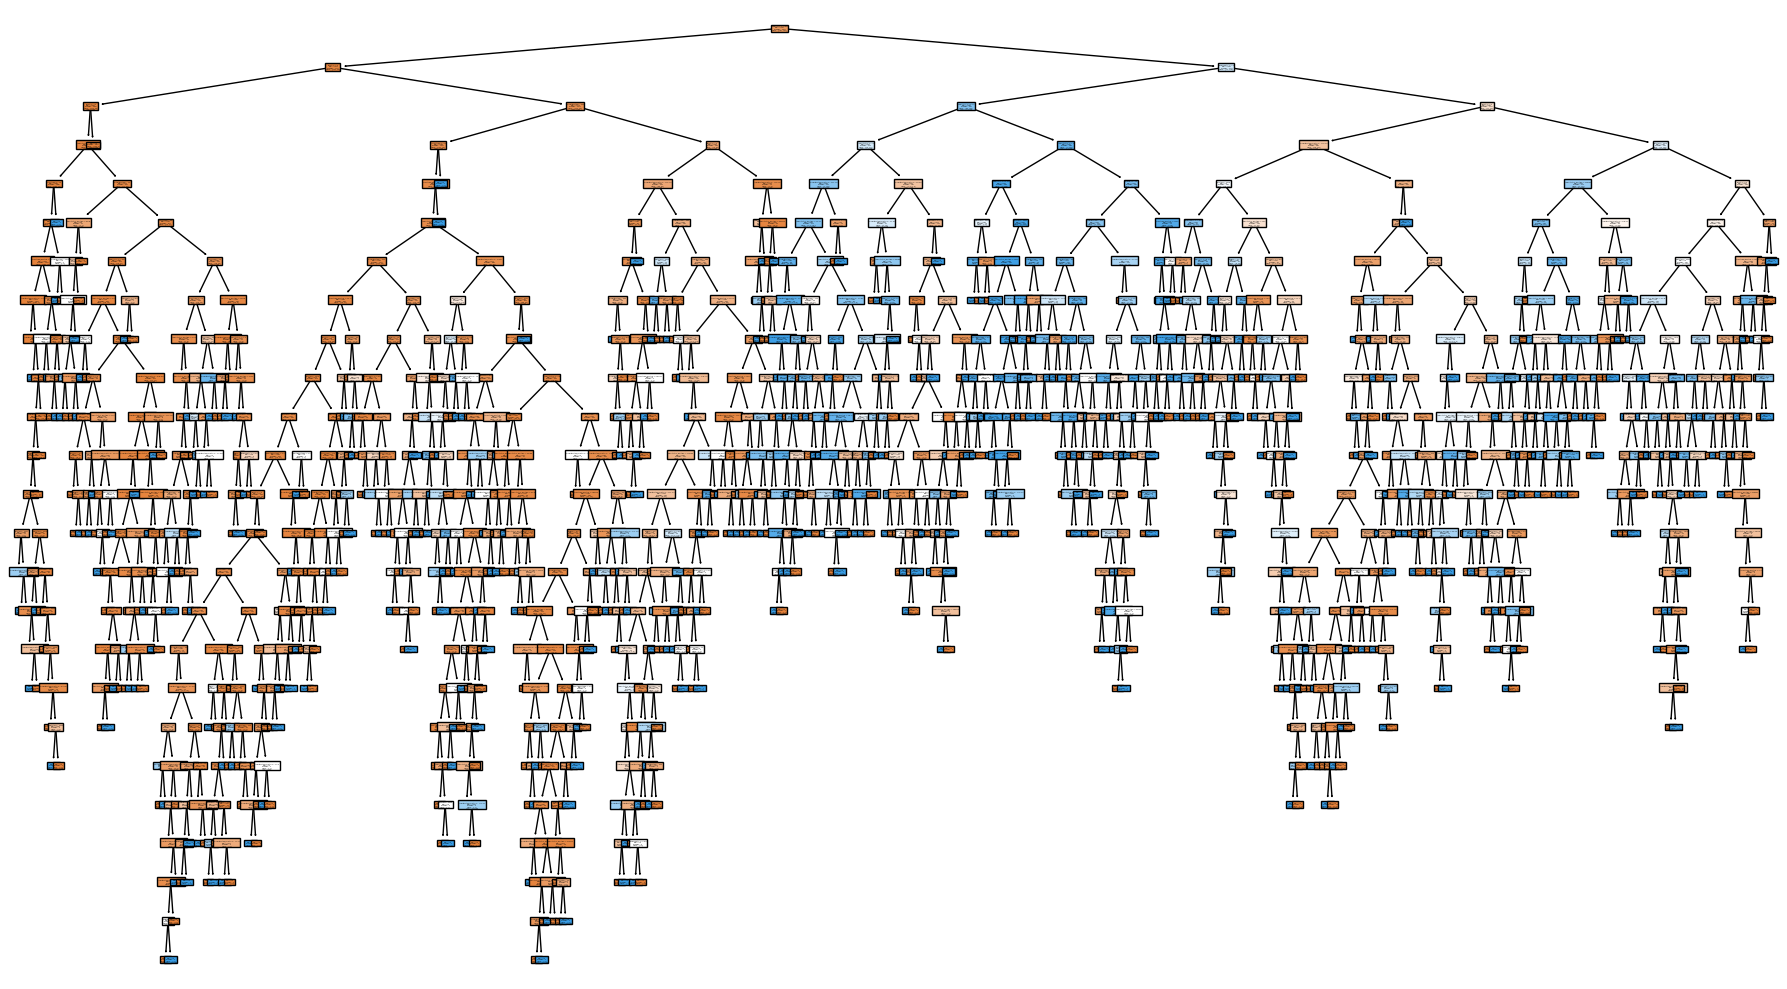

In [97]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    # max_depth=2
)

plt.tight_layout()
plt.show()

In [ ]:
max = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 25]

for depth in max:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("F1 Score: ", f1_score(y_test, y_pred))
    # print("Accuracy Score: ", accuracy_score(y_test, y_pred))

Accuracy Score:  0.8763179237631792
Accuracy Score:  0.8868613138686131
Accuracy Score:  0.8884833738848338
Accuracy Score:  0.884022708840227
Accuracy Score:  0.8864557988645579
Accuracy Score:  0.8872668288726683
Accuracy Score:  0.8896999188969992
Accuracy Score:  0.8880778588807786
Accuracy Score:  0.8815896188158961
Accuracy Score:  0.8819951338199513
Accuracy Score:  0.8698296836982968
Accuracy Score:  0.8584752635847527


In [ ]:
min_sample = [5, 10, 15, 20, 25, 30]

for split in min_sample:
    model = DecisionTreeClassifier(max_depth=3, min_samples_split=split)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("F1 Score: ", f1_score(y_test, y_pred))
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))

# Benchmark was 0.55, after Pre-Pruning we got a result of 0.64, with accuracy of 88

F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131
F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131
F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131
F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131
F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131
F1 Score:  0.6436781609195402
Accuracy Score:  0.8868613138686131


In [111]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [113]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [119]:
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("f1 score: ", f1_score(y_test, y_pred))

    tree.append((model, alpha))

best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

f1 score:  0.5728155339805825
f1 score:  0.5728155339805825
f1 score:  0.5735115431348724
f1 score:  0.5735115431348724
f1 score:  0.5735115431348724
f1 score:  0.5735115431348724
f1 score:  0.5742092457420924
f1 score:  0.5742092457420924
f1 score:  0.5759416767922235
f1 score:  0.5780487804878048
f1 score:  0.5780487804878048
f1 score:  0.5780487804878048
f1 score:  0.5780487804878048
f1 score:  0.5787545787545788
f1 score:  0.5794621026894865
f1 score:  0.5794621026894865
f1 score:  0.5801713586291309
f1 score:  0.5801713586291309
f1 score:  0.5801713586291309
f1 score:  0.5801713586291309
f1 score:  0.5808823529411765
f1 score:  0.5823095823095823
f1 score:  0.5823095823095823
f1 score:  0.5823095823095823
f1 score:  0.5823095823095823
f1 score:  0.5840490797546012
f1 score:  0.5850673194614443
f1 score:  0.5850673194614443
f1 score:  0.5850673194614443
f1 score:  0.5850673194614443
f1 score:  0.5850673194614443
f1 score:  0.5850673194614443
f1 score:  0.5840490797546012
f1 score: 

In [130]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print("F1 Score: ", f1_score(y_test, y_pred))

F1 Score:  0.6464924346629987


In [129]:
print(best_model.score(X_test, y_test))

0.8949716139497161
